<a href="https://colab.research.google.com/github/Alfredosernas/Machine-Learning/blob/main/Hands_on_6_Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clasificacion K-Means
El agrupamiento K-means es uno de los algoritmos de agrupamiento más utilizados debido a su simplicidad. En una sola frase, el agrupamiento de K-significa consiste en elegir centroides aleatorios y asignar los puntos de datos cercanos a los centroides.

#Funcionamiento del algoritmo K-Means
Así es como funciona el agrupamiento K-means. Básicamente repite mover los centoirds y asignar clústeres a puntos de datos hasta que todo converge.

1.Selecciona el número de grupos/centroides (que en este caso es 2). Localiza aleatoriamente los centroides dentro del conjunto de datos.

2.Cada punto de datos se asigna al clúster o centroide que esté más cercano a cada punto. En este caso, los puntos de datos A y B se agrupan y los puntos de datos C, D y F se agrupan juntos.

3.Una vez finalizada la asignación inicial del clúster, mueve los centroides a la ubicación media de los puntos de datos que están agrupados.

4.De nuevo, asigna cada punto de datos al centroide/clúster más cercano. En nuestro ejemplo, ahora A, B y C están agrupados mientras que D y F están agrupados.

5.Mueve los centroides a la ubicación media de los puntos de datos que están agrupados. Esto es lo mismo que el Paso 3.

6.Detén el proceso si la ubicación de los centroides ya no cambia. De lo contrario, repite los pasos 4 y 5 hasta que el algoritmo haya convergido y las asignaciones dejen de cambiar.

#Paso 1:Importamos librerias necesarias



In [2]:
from sklearn.datasets import load_iris # para el dataset
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt # para la visualizacion
import pandas as pd
import numpy as np

Aquí tienes el conjunto de datos que vamos a utilizar. El conjunto de datos contiene cuatro características (longitud y ancho del sépalo, longitud y ancho de pétalos) de los iris, así como la clase a la que pertenece cada iris. Existen tres clases: Setosa, Versicolor y Virginica. En este caso, se expresan como 0, 1, 2 bajo la columna 'objetivo'.


In [5]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Ahora generemos y entrenemos nuestro modelo de K-means.

In [6]:
kmeans = KMeans(n_clusters=3,init= 'k-means++',max_iter= 300, random_state=0)
kmeans.fit(iris.data)
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


Usando los retornos a qué clúster/centroide pertenece cada punto de datos.labels_

Ahora comparemos el agrupamiento realizado por nuestro modelo k-means y las clases reales.

In [9]:
df['cluster'] = kmeans.labels_
df.groupby(['target','cluster']).agg({'sepal length (cm)':'count'})

sepal length (cm)
target cluster                   
0      1                       50
1      0                       47
       2                        3
2      0                       14
       2                       36

Como se puede ver arriba, todo el Objetivo 0 está clasificado como Clúster 1. Podemos decir que los iris que pertenecen al Objetivo 0 están agrupados muy bien. Para el Objetivo 1, 48 de 50 iris están agrupados como Clúster 0 mientras que 2 están agrupados como Clúster 2. Sin embargo, para el Objetivo 2, el 14 se agrupa como el Clúster 0 y el 36 se agrupa juntos como Clúster 2.

intentemos ahora visualizar el resultado de agrupamiento. Como tenemos cuatro características, reduciremos la dimensión a 2 para poder expresar el resultado en el plano x-y. Para la reducción de dimensiones, usemos el método PCA

In [11]:
from sklearn.decomposition import PCA
pca = PCA(2)
pca_res = pca.fit_transform(iris.data)
df['x'] = pca_res[:,0]
df['y'] = pca_res[:,1]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster,x,y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,-2.728717,0.326755


Nuestras cuatro características (longitud del sépalo, ancho del sépalo, longitud y ancho del pétalo) se han reducido ahora a solo dos características, X e Y. Ahora podemos visualizar los clústeres asignados usando nuestro modelo k-medias que pueden visualizarse en un gráfico 2D.

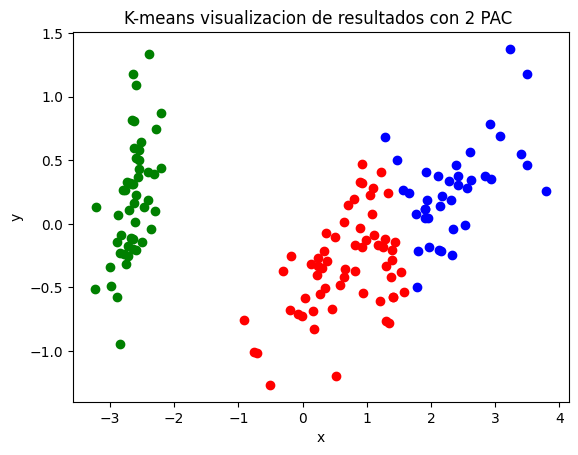

In [15]:
cluster_0 = df[df['cluster']== 0]
cluster_1 = df[df['cluster']== 1]
cluster_2 = df[df['cluster']== 2]
plt.scatter(cluster_0['x'], cluster_0['y'],label = 'closter 0' ,color='red')
plt.scatter(cluster_1['x'], cluster_1['y'],label = 'closter 1', color='green')
plt.scatter(cluster_2['x'], cluster_2['y'],label = 'closter 2', color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title('K-means visualizacion de resultados con 2 PAC ')
plt.show()

Como se puede ver, el Clúster 0 y el Clúster 2 están muy cerca uno del otro, mientras que el Clúster 1 está situado relativamente lejos de los otros dos clústeres. Esto explica por qué el Clúster 0 y el Clúster 2 aparecieron juntos bajo el Objetivo 1 y el Objetivo 2.